# 05 · Comparison of the four models

**Owner:** Tanishq Sharma  
Common protocol: de Chazal DS1/DS2 inter-patient split, same preprocessed beats, same metric code (`src/evaluate.py`), mean ± std over seeds 42/43/44. Script: `src/compare.py`.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
!cd .. && python src/compare.py > /dev/null
from IPython.display import Markdown, Image, display
display(Markdown(open(os.path.join(ROOT, "results", "comparison.md")).read()))

zsh:1: command not found: python


# Model comparison on DS2 (inter-patient test set)

Mean ± standard deviation over seeds 42, 43, 44. Macro averages over the five AAMI classes unless marked N/S/V/F.

| Model | Accuracy | Macro precision | Macro recall | Macro-F1 | Macro-F1 (N/S/V/F) |
|---|---|---|---|---|---|
| M1 Random Forest | 0.939 ± 0.000 | 0.518 ± 0.003 | 0.358 ± 0.001 | 0.371 ± 0.001 | 0.463 ± 0.001 |
| M2 1D CNN (DE/PSO-tuned) | 0.893 ± 0.041 | 0.429 ± 0.030 | 0.404 ± 0.015 | 0.360 ± 0.056 | 0.449 ± 0.070 |
| M3 BiGRU | 0.891 ± 0.005 | 0.323 ± 0.013 | 0.360 ± 0.010 | 0.333 ± 0.010 | 0.416 ± 0.012 |
| M4 Transformer | 0.904 ± 0.031 | 0.413 ± 0.066 | 0.409 ± 0.004 | 0.392 ± 0.033 | 0.489 ± 0.043 |
| M2 1D CNN (untuned default) | 0.927 ± 0.011 | 0.416 ± 0.033 | 0.405 ± 0.038 | 0.386 ± 0.048 | 0.482 ± 0.060 |

## Per-class recall (sensitivity)

| Model | N | S | V | F | Q |
|---|---|---|---|---|---|
| M1 Random Forest | 0.998 | 0.014 | 0.779 | 0.000 | 0.000 |
| M2 1D CNN (DE/PSO-tuned) | 0.929 | 0.123 | 0.938 | 0.027 | 0.000 |
| M3 BiGRU | 0.939 | 0.026 | 0.827 | 0.009 | 0.000 |
| M4 Transformer | 0.944 | 0.197 | 0.857 | 0.001 | 0.048 |
| M2 1D CNN (untuned default) | 0.970 | 0.158 | 0.898 | 0.000 | 0.000 |

## Per-class F1

| Model | N | S | V | F | Q |
|---|---|---|---|---|---|
| M1 Random Forest | 0.967 | 0.027 | 0.859 | 0.000 | 0.000 |
| M2 1D CNN (DE/PSO-tuned) | 0.950 | 0.184 | 0.647 | 0.018 | 0.000 |
| M3 BiGRU | 0.946 | 0.040 | 0.674 | 0.005 | 0.000 |
| M4 Transformer | 0.948 | 0.254 | 0.753 | 0.001 | 0.006 |
| M2 1D CNN (untuned default) | 0.967 | 0.171 | 0.790 | 0.000 | 0.000 |

DS2 support: N 44228, S 1836, V 3220, F 388, Q 7


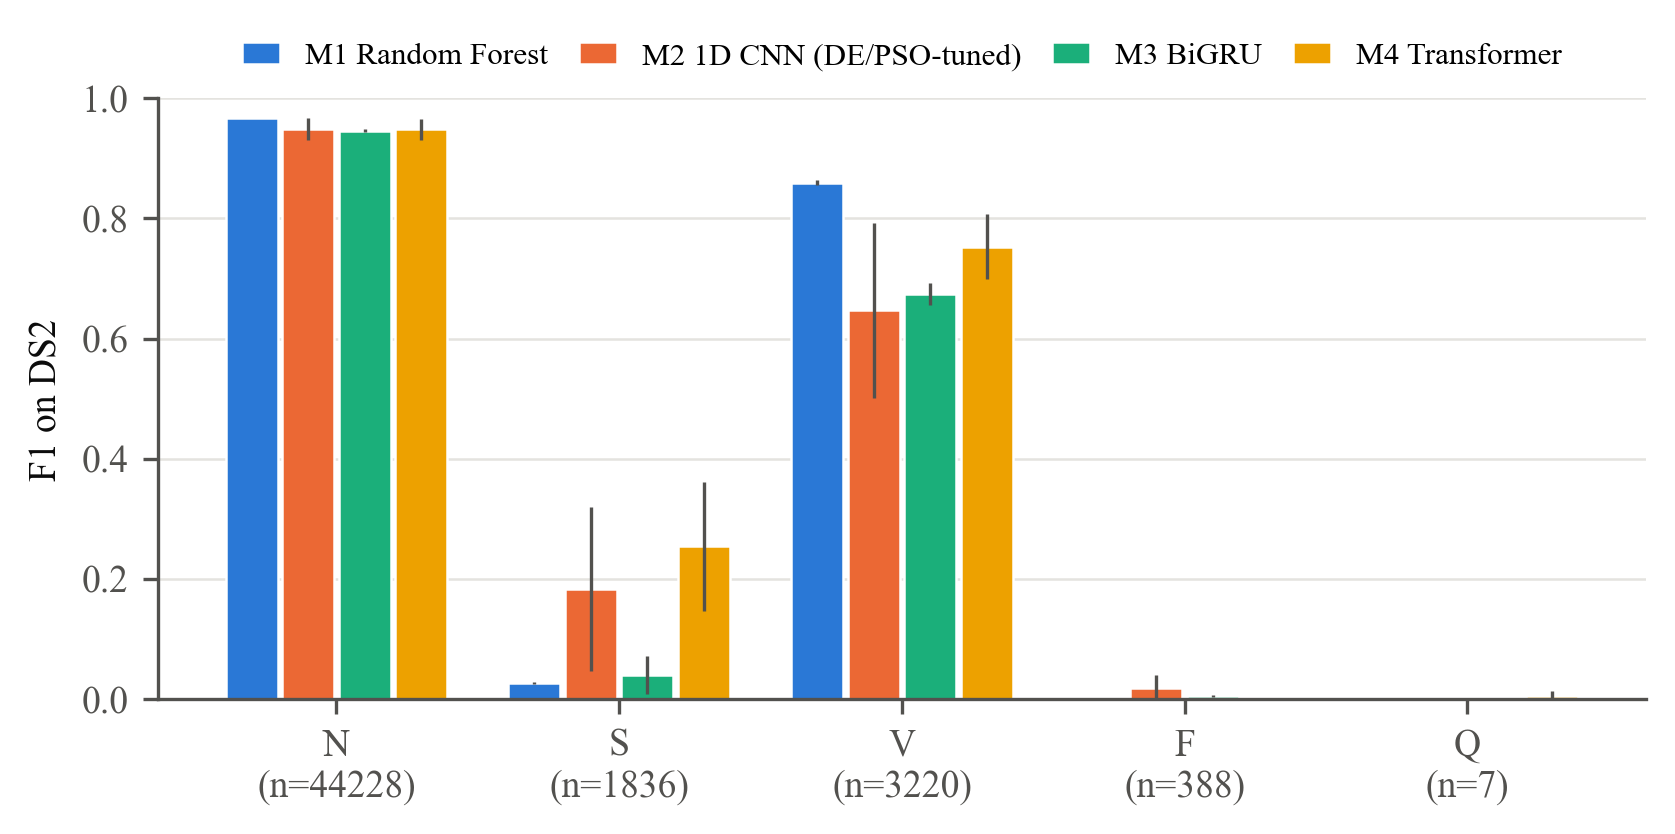

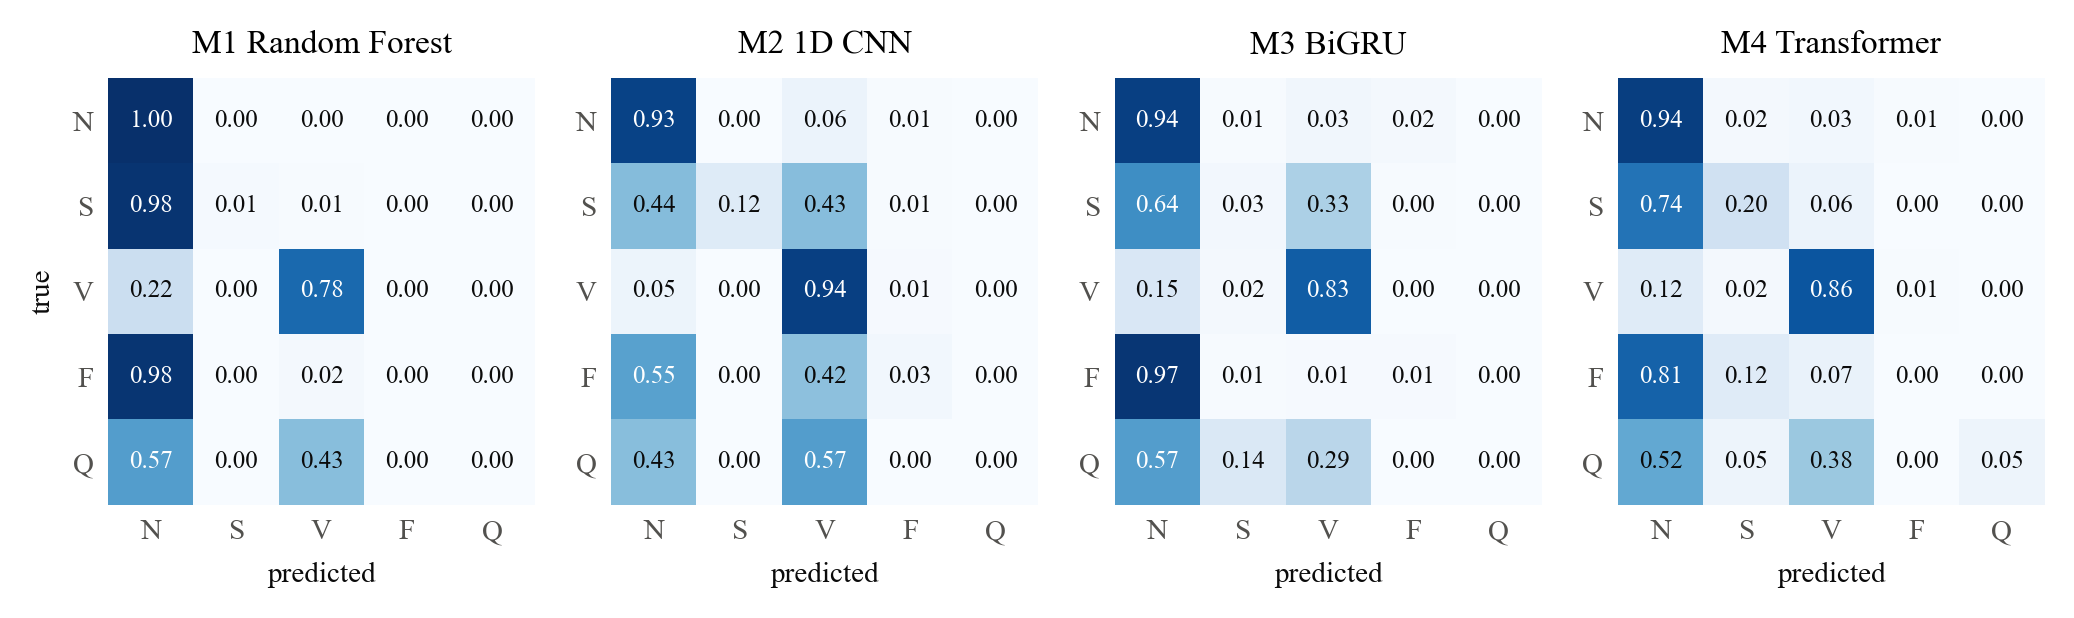

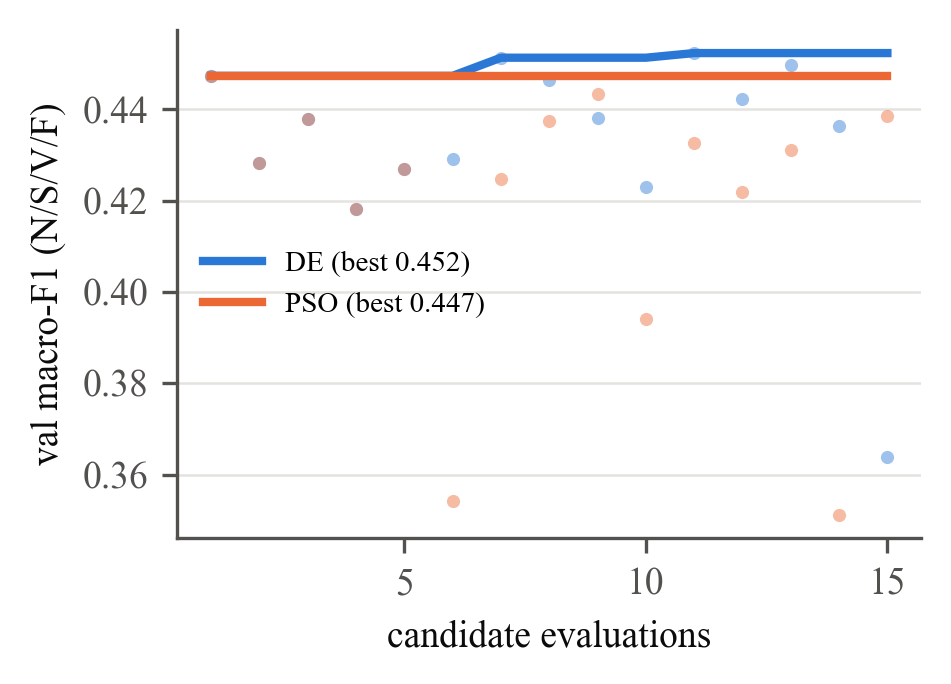

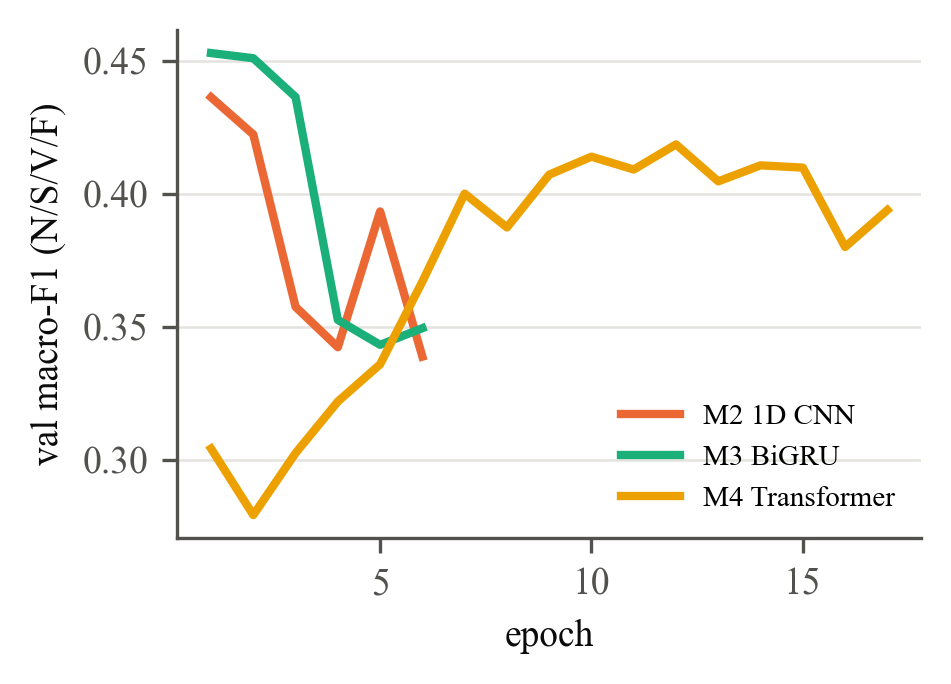

In [3]:
for f in ["per_class_f1", "confusion_matrices", "cnn_search", "learning_curves"]:
    display(Image(os.path.join(ROOT, "figures", f + ".png"), width=700))

## Patient-level bootstrap 95% confidence intervals
The 22 DS2 records are resampled with replacement (2,000 draws, `src/bootstrap_ci.py`). Resampling beats instead would understate the uncertainty, because 75% of DS2 S beats come from record 232 and 93% of F beats from record 213.

In [4]:
ci = json.load(open(os.path.join(ROOT, 'results', 'bootstrap_ci.json')))
print(f"{'model':18s} macro-F1   95% CI")
for tag, r in ci['models'].items():
    m = r['macro_f1']
    print(f"{tag:18s} {m['point']:.3f}    [{m['ci95'][0]:.3f}, {m['ci95'][1]:.3f}]")
print('All intervals overlap: no model is statistically better on 22 test patients.')

model              macro-F1   95% CI
m1_random_forest   0.371    [0.339, 0.418]
m2_cnn1d_tuned     0.360    [0.313, 0.405]
m3_bigru           0.333    [0.279, 0.376]
m4_transformer     0.392    [0.333, 0.423]
m2_cnn1d_default   0.386    [0.341, 0.404]
All intervals overlap: no model is statistically better on 22 test patients.


# Final phase: interim vs final, confidence intervals and per-patient errors

In [5]:
!cd .. && python src/bootstrap_ci.py --final > /dev/null && python src/compare.py --final > /dev/null
display(Markdown(open(os.path.join(ROOT, 'results', 'final', 'comparison_final.md')).read()))

zsh:1: command not found: python


# Final-phase results on DS2

Final models: trained on all 22 DS1 patients with the configuration and epoch count chosen by 4-fold grouped cross-validation on DS1; calibration offsets fitted on the out-of-fold DS1 predictions. DS2 scored once. Mean ± std over seeds 42/43/44; CI = patient-level bootstrap.

## Interim vs final (macro-F1 over 5 classes)

| Model | Interim | Interim 95% CI | Final raw | Final raw 95% CI | Final calibrated | Final cal. 95% CI |
|---|---|---|---|---|---|---|
| M1 Random Forest | 0.371 ± 0.001 | [0.339, 0.418] | 0.388 ± 0.000 | [0.368, 0.439] | 0.399 ± 0.001 | [0.369, 0.451] |
| M2 1D CNN | 0.360 ± 0.056 | [0.313, 0.405] | 0.381 ± 0.036 | [0.341, 0.407] | 0.370 ± 0.037 | [0.329, 0.401] |
| M3 BiGRU | 0.333 ± 0.010 | [0.279, 0.376] | 0.353 ± 0.033 | [0.296, 0.403] | 0.351 ± 0.035 | [0.288, 0.405] |
| M4 Transformer | 0.392 ± 0.033 | [0.333, 0.423] | 0.374 ± 0.023 | [0.307, 0.449] | 0.383 ± 0.020 | [0.320, 0.455] |

## Final raw: all metrics

| Model | Accuracy | Macro-F1 | Macro-F1 (N/S/V/F) | Rec. N | Rec. S | Rec. V | Rec. F | F1 S | F1 V |
|---|---|---|---|---|---|---|---|---|---|
| M1 Random Forest | 0.941 ± 0.000 | 0.388 ± 0.000 | 0.485 ± 0.000 | 0.99 | 0.04 | 0.88 | 0.00 | 0.06 | 0.91 |
| M2 1D CNN | 0.924 ± 0.020 | 0.381 ± 0.036 | 0.476 ± 0.045 | 0.98 | 0.25 | 0.61 | 0.02 | 0.25 | 0.67 |
| M3 BiGRU | 0.828 ± 0.035 | 0.353 ± 0.033 | 0.442 ± 0.042 | 0.85 | 0.29 | 0.87 | 0.07 | 0.30 | 0.52 |
| M4 Transformer | 0.885 ± 0.032 | 0.374 ± 0.023 | 0.467 ± 0.029 | 0.92 | 0.13 | 0.87 | 0.11 | 0.15 | 0.74 |

## Final calibrated: all metrics

| Model | Accuracy | Macro-F1 | Macro-F1 (N/S/V/F) | Rec. N | Rec. S | Rec. V | Rec. F | F1 S | F1 V |
|---|---|---|---|---|---|---|---|---|---|
| M1 Random Forest | 0.880 ± 0.003 | 0.399 ± 0.001 | 0.498 ± 0.001 | 0.92 | 0.10 | 0.87 | 0.11 | 0.12 | 0.91 |
| M2 1D CNN | 0.925 ± 0.019 | 0.370 ± 0.037 | 0.463 ± 0.046 | 0.99 | 0.22 | 0.57 | 0.00 | 0.24 | 0.64 |
| M3 BiGRU | 0.831 ± 0.035 | 0.351 ± 0.035 | 0.439 ± 0.043 | 0.86 | 0.38 | 0.83 | 0.03 | 0.30 | 0.53 |
| M4 Transformer | 0.892 ± 0.027 | 0.383 ± 0.020 | 0.479 ± 0.025 | 0.94 | 0.12 | 0.81 | 0.14 | 0.15 | 0.76 |

## What grouped cross-validation chose (CV macro-F1 over N/S/V/F on DS1)

| Model | Steps tried (CV macro-F1, kept/rejected) | Selected | Epochs | Offsets (N,S,V,F,Q) |
|---|---|---|---|---|
| M1 Random Forest | baseline 0.429 (kept); relRR 0.441 (kept); smote 0.464 (kept) | baseline+relRR+smote | - | +0.00, +0.75, +0.00, +1.25, +0.00 |
| M2 1D CNN | baseline 0.459 (kept); context 0.440 (rejected); augment 0.517 (kept); focal 0.508 (rejected); de-tuned 0.511 (rejected) | baseline+augment | 5 | +0.00, -0.50, -0.75, -1.75, +0.00 |
| M3 BiGRU | baseline 0.444 (kept); context 0.443 (rejected); augment 0.450 (rejected); focal 0.453 (rejected) | baseline | 8 | +0.00, +0.75, -0.50, -1.00, +0.00 |
| M4 Transformer | baseline 0.449 (kept); context 0.466 (kept); augment 0.517 (kept); focal 0.485 (rejected) | baseline+context+augment | 12 | +0.00, -0.75, -1.75, +0.00, +0.00 |

## Per-record recall (calibrated, DS2 records with at least 30 S or 30 V beats)

| Record | S beats | S rec. M1 Random Forest | S rec. M2 1D CNN | S rec. M3 BiGRU | S rec. M4 Transformer | V beats | V rec. M1 Random Forest | V rec. M2 1D CNN | V rec. M3 BiGRU | V rec. M4 Transformer |
|---|---|---|---|---|---|---|---|---|---|---|
| 100 | 33 | 0.03 | 0.12 | 0.99 | 0.97 | 1 | 1.00 | 0.33 | 1.00 | 1.00 |
| 105 | 0 | - | - | - | - | 41 | 0.82 | 0.06 | 0.86 | 0.72 |
| 200 | 30 | 0.42 | 0.11 | 0.76 | 0.33 | 826 | 0.90 | 0.63 | 0.90 | 0.90 |
| 202 | 55 | 0.62 | 0.61 | 0.85 | 0.71 | 19 | 0.39 | 0.51 | 0.58 | 0.51 |
| 210 | 22 | 0.00 | 0.05 | 0.76 | 0.11 | 195 | 0.78 | 0.49 | 0.69 | 0.76 |
| 213 | 28 | 0.00 | 0.07 | 0.76 | 0.01 | 220 | 0.68 | 0.24 | 0.82 | 0.47 |
| 214 | 0 | - | - | - | - | 256 | 0.90 | 0.58 | 0.70 | 0.73 |
| 219 | 7 | 0.14 | 0.05 | 0.29 | 0.19 | 64 | 0.88 | 0.80 | 0.95 | 0.90 |
| 221 | 0 | - | - | - | - | 396 | 0.99 | 0.94 | 0.99 | 1.00 |
| 222 | 209 | 0.53 | 0.28 | 0.41 | 0.42 | 0 | - | - | - | - |
| 228 | 3 | 0.00 | 0.11 | 0.11 | 0.11 | 362 | 0.92 | 0.33 | 0.96 | 0.89 |
| 232 | 1381 | 0.01 | 0.21 | 0.33 | 0.03 | 0 | - | - | - | - |
| 233 | 7 | 0.00 | 0.10 | 0.00 | 0.00 | 830 | 0.85 | 0.54 | 0.70 | 0.72 |
| 234 | 50 | 0.00 | 0.00 | 0.07 | 0.03 | 3 | 0.33 | 0.11 | 0.78 | 0.22 |

## Effect of record 232 on S recall (calibrated)

| Model | S recall, all DS2 | record 232 only | all other records |
|---|---|---|---|
| M1 Random Forest | 0.098 | 0.010 | 0.365 |
| M2 1D CNN | 0.216 | 0.207 | 0.246 |
| M3 BiGRU | 0.379 | 0.331 | 0.525 |
| M4 Transformer | 0.123 | 0.033 | 0.396 |


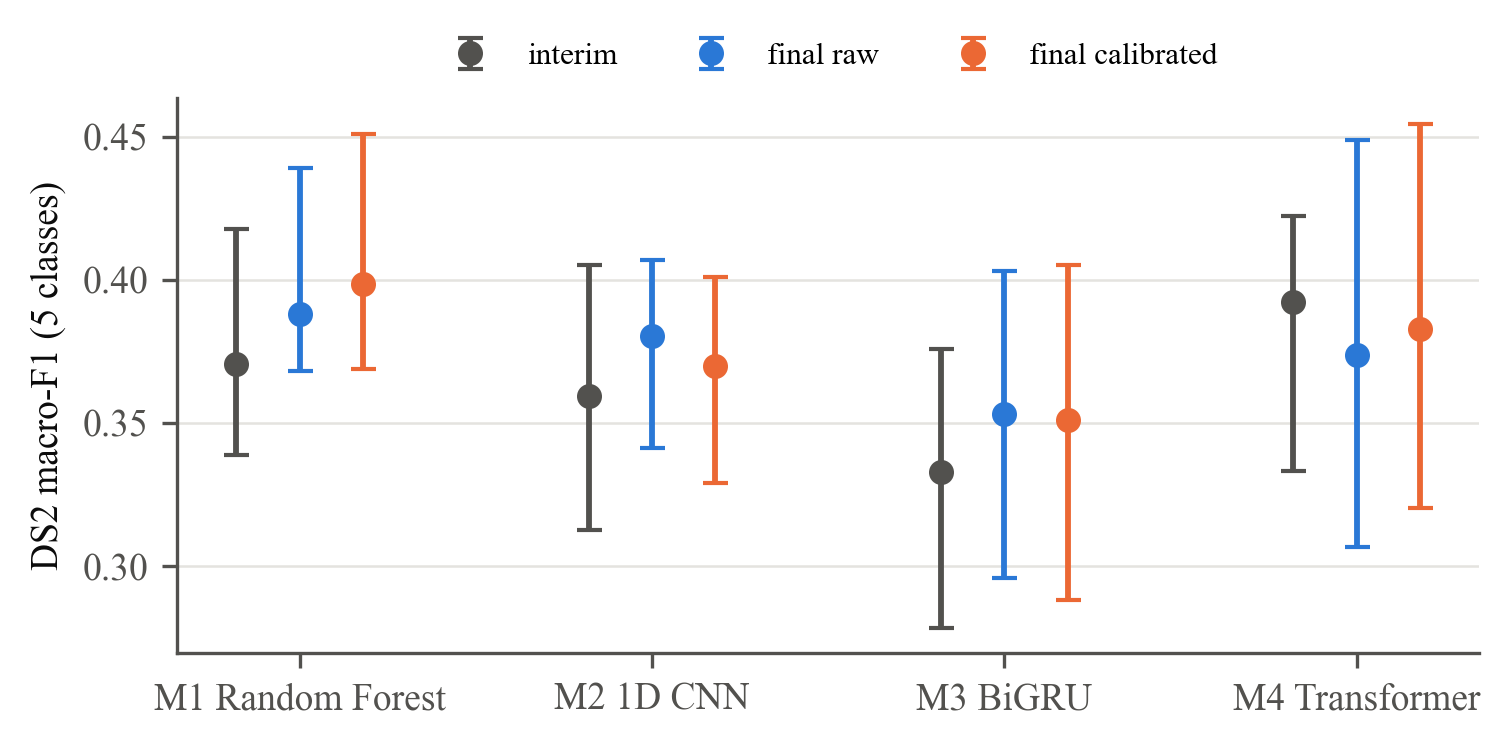

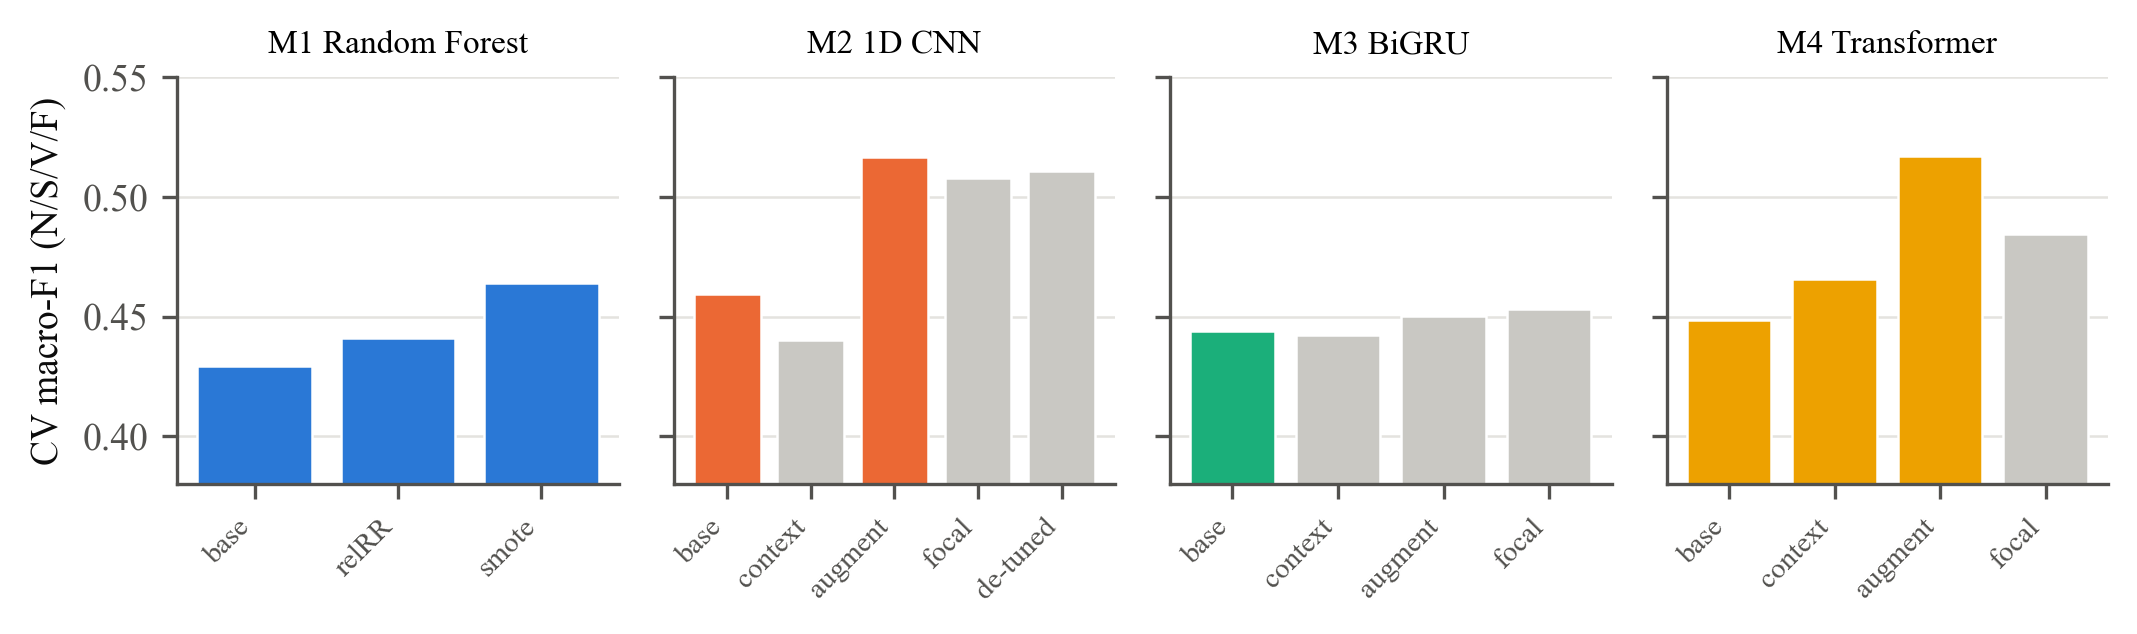

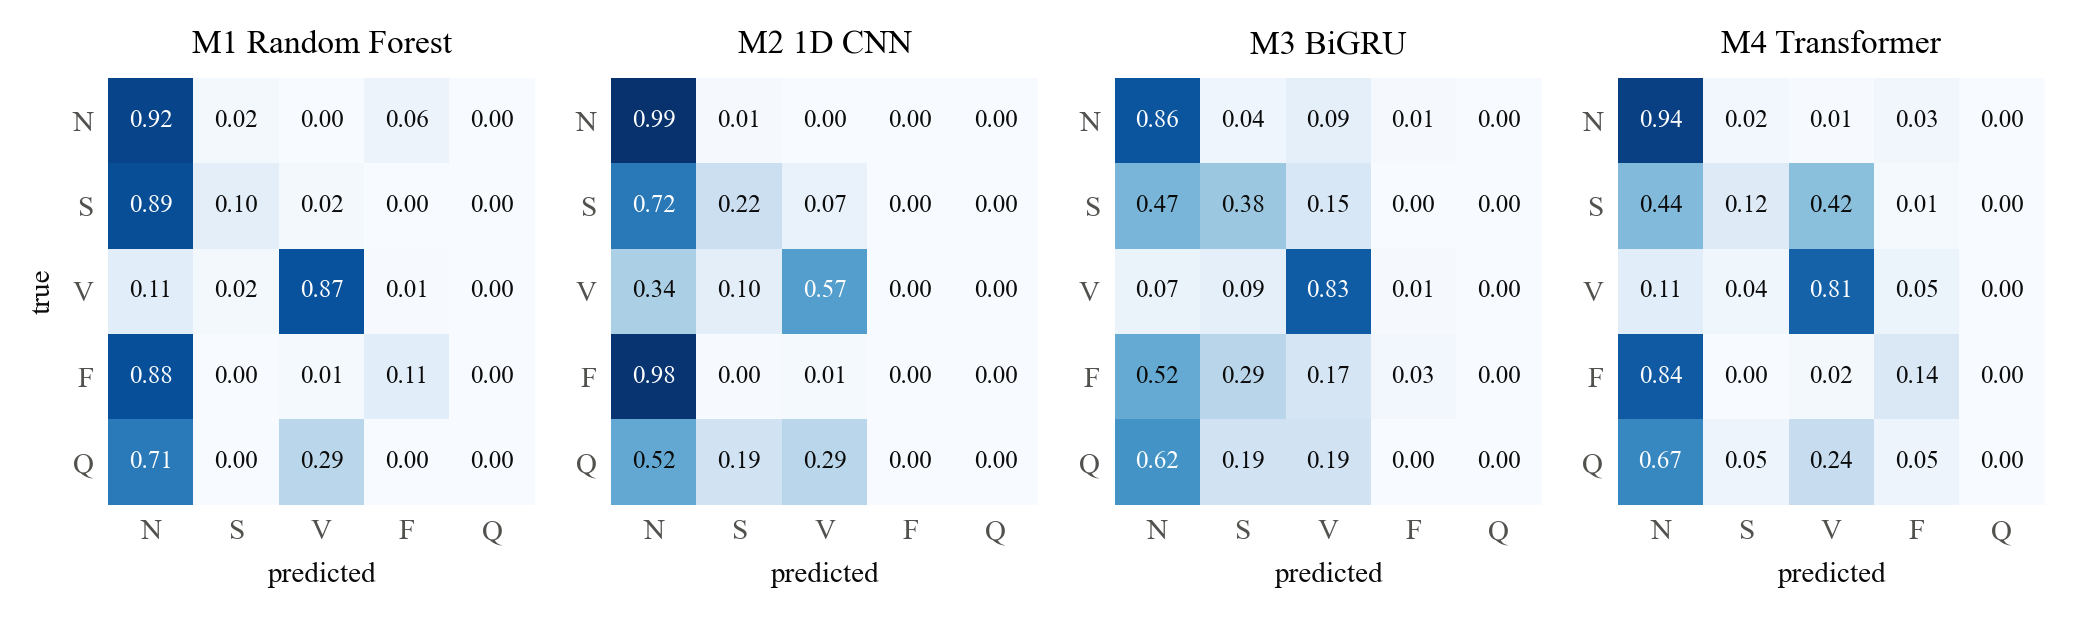

In [6]:
for f in ['final_vs_interim', 'final_cv_ablation', 'final_confusion_matrices']:
    display(Image(os.path.join(ROOT, 'figures', f + '.png'), width=760))